# Estimating Vaccine Efficacy from a Randomized Trial via Time-to-First-Infection

## Executive Summary

## Estimating vaccine efficacy from a randomized trial

A pivotal Phase III vaccine trial randomizes participants 1:1 to **vaccine** or **placebo** and follows each person until their first laboratory-confirmed infection or until administrative censoring at the end of the enrollment-and-follow-up window. The regulatory primary endpoint is **vaccine efficacy (VE)**, defined as `VE = 1 - hazard ratio (vaccine vs. placebo)`. Because participants enter on a staggered schedule and most never get infected, the data are right-censored and survival methods — not simple proportions — give the defensible estimate.

This notebook works the endpoint end-to-end on a synthetic balanced trial of **100 subjects (50 vaccine, 50 placebo)**:

- **PROC FREQ** builds the attack-rate two-by-two (arm by infection status) with the chi-square test, relative risk, and risk difference — the descriptive "crude VE" view a clinical reviewer sees first.
- **PROC MEANS** summarizes person-time (total and mean follow-up days) and the raw infection counts per arm, exposing the censoring imbalance that motivates a time-to-event model.
- **PROC LIFETEST** estimates the Kaplan-Meier survivor curves by arm and runs the **log-rank and Wilcoxon** homogeneity tests — the nonparametric confirmation that the curves separate.
- **PROC PHREG** fits the Cox proportional-hazards model adjusting for age, sex, and baseline exposure risk, reports the hazard ratio with its 95% confidence limits, and the **HAZARDRATIO** statement frames the arm contrast directly. The adjusted VE is read off as `1 - HR`.

**How to read the result.** In the verified run the crude infection proportion is **64% in placebo versus 30% in vaccine** (chi-square p = 0.0007), the log-rank test rejects equality of the survival curves (χ² = 11.25, p = 0.0008), and the adjusted Cox hazard ratio for vaccine vs. placebo is **0.369** with a 95% CI of **(0.198, 0.687)** — entirely below 1 — i.e. an estimated VE of about **63%** (`1 - 0.369`). The upper HR confidence limit of 0.687 maps to a lower efficacy bound near 31%, at the edge of the conventional 30-50% licensure threshold for a study this small. Baseline high-exposure occupation roughly triples the infection hazard (HR = 3.47, p < .0001), confirming the covariate adjustment matters; age and sex carry borderline effects (p ≈ 0.06) that do not reach significance at the 0.05 level. The consistency of the crude two-by-two, the separated KM curves, and the adjusted Cox estimate is exactly the triangulation a Data Safety Monitoring Board expects before declaring efficacy.

*Synthetic data only — generated inline with `streaminit`/`rand`; no external files or network. Runs in well under a minute.*

## Data Sources

**Synthetic dataset `trial`** — one row per enrolled participant, generated inline in the first code cell (seed `20260605`). 100 subjects, balanced 1:1 (50 vaccine, 50 placebo), exponential time-to-infection with a ~70% hazard reduction in the vaccine arm, staggered entry, and administrative censoring at the end of a 540-day window.

| Variable | Type | Description |
|----------|------|-------------|
| `subjid` | Num | Subject identifier (1-100) |
| `arm` | Char | Treatment arm: `Vaccine` or `Placebo` |
| `arm_n` | Num | Numeric arm flag (1 = vaccine, 0 = placebo) |
| `age` | Num | Age in years at enrollment (18-85) |
| `sex` | Char | Sex: `F` or `M` |
| `baseline_risk` | Num | High-exposure occupation indicator (1 = yes) |
| `fu_days` | Num | Follow-up time in days to first infection or censoring |
| `infected` | Num | Event indicator: 1 = infection observed, 0 = censored |

# Estimating Vaccine Efficacy from a Randomized Trial

**Time-to-first-infection survival analysis**

The primary efficacy endpoint of a vaccine trial is the **hazard of infection** in the vaccine arm relative to placebo. We define

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

Because participants enter on a staggered schedule and most are never infected before follow-up ends, the data are right-censored: a simple proportion-of-infected comparison wastes the timing information and is biased by unequal follow-up. We therefore build the estimate in three layers — a crude attack-rate two-by-two, nonparametric Kaplan-Meier curves with a log-rank test, and an adjusted Cox proportional-hazards model — and check that all three tell the same story.

The analysis uses **PROC FREQ**, **PROC MEANS**, **PROC LIFETEST**, and **PROC PHREG**.

## 1. Generate the synthetic trial

We simulate a balanced 100-subject, 1:1 randomized trial (50 vaccine, 50 placebo — assigned by subject parity so the arms are exactly equal). Time to first infection is drawn from an exponential distribution whose per-day hazard depends on arm (the vaccine cuts the hazard to 30% of placebo), age, and a high-exposure occupation flag. Staggered entry plus a fixed 540-day window produces realistic right-censoring: anyone not infected by the end of their follow-up is censored.

In [1]:
/* Synthetic randomized vaccine trial: time to first infection */
data trial;
    call streaminit(20260605);
    enroll_days = 540;            /* enrollment + follow-up window */
    do subjid = 1 to 100;
        /* 1:1 randomization to vaccine vs placebo: 50 per arm,
           assigned by alternating parity for an exactly balanced trial */
        if mod(subjid, 2) = 1 then do;
            arm = 'Vaccine'; arm_n = 1;
        end;
        else do;
            arm = 'Placebo'; arm_n = 0;
        end;

        /* baseline covariates */
        age = round(rand('NORMAL', 47, 14));
        if age < 18 then age = 18;
        if age > 85 then age = 85;
        if rand('BERNOULLI', 0.52) = 1 then sex = 'F'; else sex = 'M';
        baseline_risk = rand('BERNOULLI', 0.30);   /* high-exposure occupation */

        /* per-day infection hazard: placebo baseline, vaccine cuts it ~70% */
        base_rate = 0.0016;
        rr_age  = exp(0.012 * (age - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        if arm_n = 1 then ve_factor = 0.30; else ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        /* time to first infection from exponential hazard */
        u = rand('UNIFORM');
        t_inf = -log(u) / daily_hazard;

        /* administrative censoring at staggered entry */
        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        if t_inf <= t_cens then do;
            fu_days = round(t_inf);
            infected = 1;
        end;
        else do;
            fu_days = round(t_cens);
            infected = 0;
        end;
        if fu_days < 1 then fu_days = 1;
        output;
    end;
    keep subjid arm arm_n age sex baseline_risk fu_days infected;
run;

NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Attack-rate two-by-two

The simplest efficacy view: cross-tabulate arm against infection status. The chi-square test asks whether infection is independent of arm; `RELRISK` reports the relative risk and odds ratio; `RISKDIFF` gives the absolute risk difference with its confidence interval. This is the *crude* (unadjusted, follow-up-ignoring) picture — useful as a sanity check but not the regulatory estimate.

                                                   The FREQ Procedure

Table of arm by infected

arm     |         0 |         1 |      Total
--------+-----------+-----------+-----------
Placebo |        18 |        32 |         50
--------+-----------+-----------+-----------
Vaccine |        35 |        15 |         50
--------+-----------+-----------+-----------
Total   |        53 |        47 |        100

Statistics for Table of arm by infected

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's Exact Test                                      0.0012

Phi Coefficient                      0.3406
Contingency Coefficient              0.3224
Cramer's V                           0.3406


Column 1 Risk Estimates

Risk (Row 1)                         0.3600
Risk (Row 2)         

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


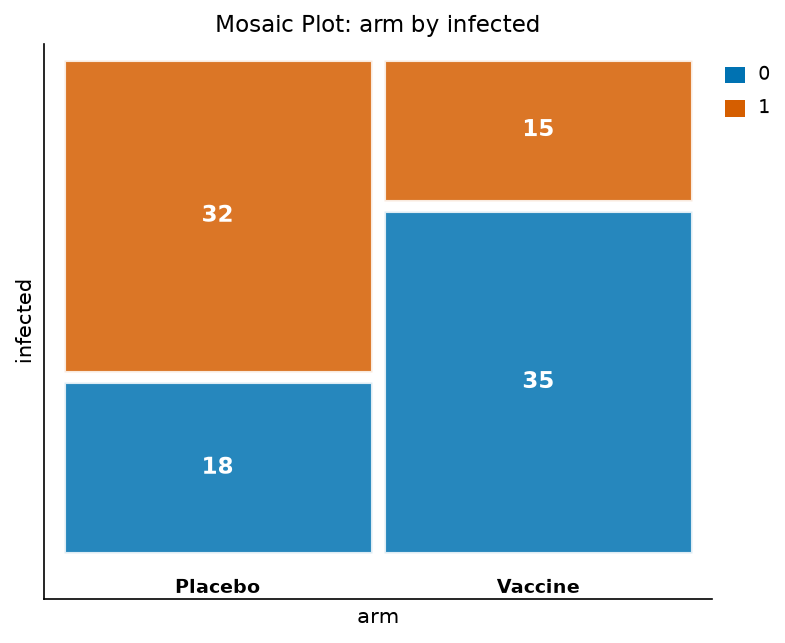

In [2]:
proc freq data=trial;
    tables arm*infected / chisq relrisk riskdiff nocol nopercent;
run;

## 3. Person-time and event counts by arm

Before trusting the crude two-by-two we quantify the follow-up imbalance. `PROC MEANS` reports total and mean follow-up days plus the infection count in each arm. If the vaccine arm accumulates *more* person-time (fewer early events), the crude proportion understates efficacy — which is exactly why we move to a time-to-event model next.

In [3]:
proc means data=trial n sum mean maxdec=2;
    class arm;
    var fu_days infected;
run;

                                                  The MEANS Procedure

                                              Analysis Variable : fu_days

        arm               N Obs            Sum           Mean
        -----------------------------------------------------
        Placebo              50       14552.00         291.04
        Vaccine              50       19438.00         388.76
        -----------------------------------------------------

                                              Analysis Variable : infected

        arm               N Obs            Sum           Mean
        -----------------------------------------------------
        Placebo              50          32.00           0.64
        Vaccine              50          15.00           0.30
        -----------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Kaplan-Meier curves and log-rank test

`PROC LIFETEST` estimates the product-limit (Kaplan-Meier) survivor function — here, the probability of remaining infection-free over time — separately for each arm. `STRATA arm / test=(logrank wilcoxon)` requests the two standard homogeneity tests: the **log-rank** test weights all event times equally (most powerful under proportional hazards), while **Wilcoxon** up-weights early events. Agreement between them supports the proportional-hazards assumption the Cox model will rely on. `ATRISK` annotates the number still at risk.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

    Stratum: arm = Placebo    

                             N
--------------------  --------
Total                       50
Event                       32
Censored                    18
Median Survival Time  324.0000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  9.0000    0.9800     0.0198              50                 1
 17.0000    0.9600     0.0277              49                 1
 23.0000    0.9400     0.0336              48                 1
 26.0000    0.9200     0.0384              47                 1
 39.0000    0.9000     0.0424              46                 1
 40.0000    0.8800     0.0460              45    

NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: lifetest_survival.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


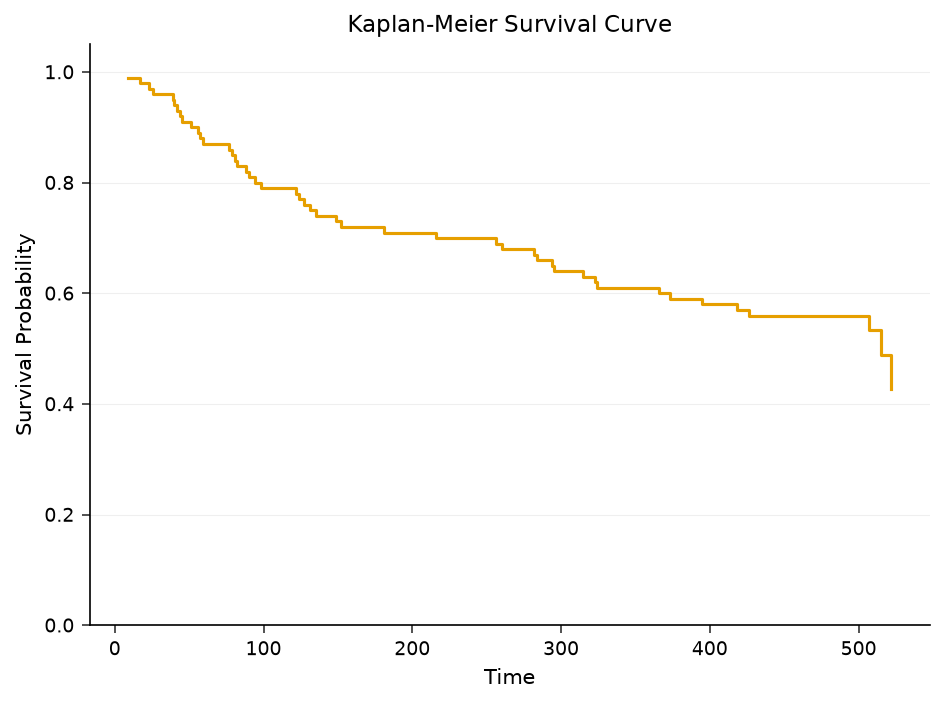

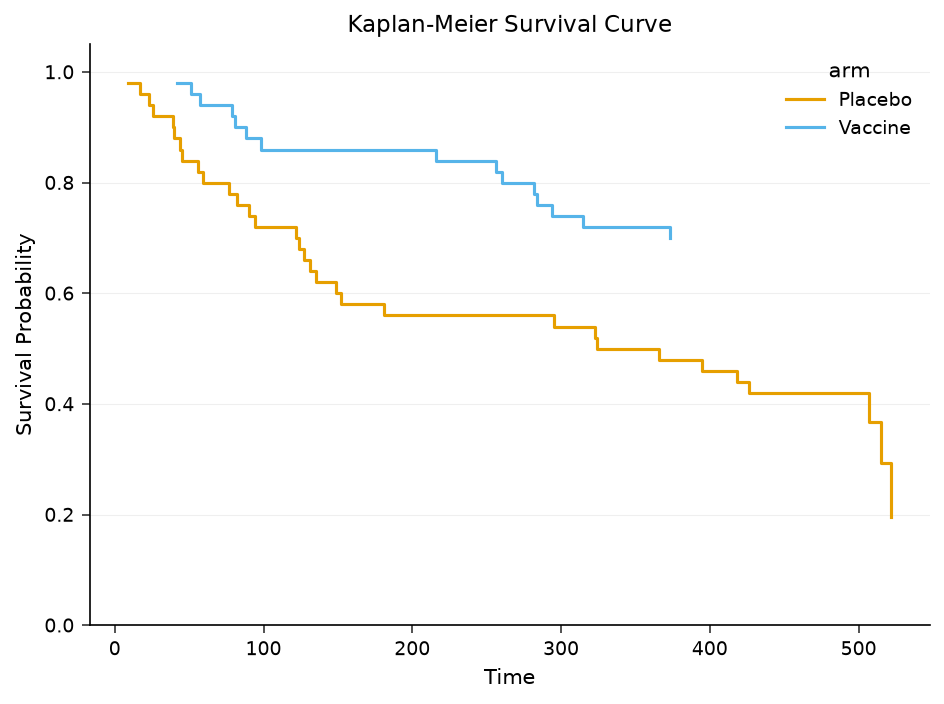

In [4]:
proc lifetest data=trial plots=survival atrisk;
    time fu_days*infected(0);
    strata arm / test=(logrank wilcoxon);
run;

## 5. Adjusted Cox model and vaccine efficacy

The Cox proportional-hazards model gives the **adjusted** hazard ratio, controlling for age, sex, and baseline exposure risk. `CLASS arm(ref='Placebo') sex(ref='M') / param=ref` sets reference coding so the `ARM` coefficient is the log hazard ratio of vaccine vs. placebo. `TIES=EFRON` is the recommended tie-handling method; `RL` prints the hazard-ratio confidence limits. The `HAZARDRATIO` statements report the arm contrast (Wald CL) and the age effect per 10-year increment.

**Vaccine efficacy is read directly as `VE = 1 - HR` for the arm term**, and the upper confidence limit of the HR maps to the lower efficacy bound that licensure decisions hinge on.

In [5]:
proc phreg data=trial;
    class arm(ref='Placebo') sex(ref='M') / param=ref;
    model fu_days*infected(0) = arm age sex baseline_risk / ties=efron rl;
    hazardratio 'Vaccine vs Placebo' arm / cl=wald;
    hazardratio age / units=10;
run;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                     Analysis of Maximum Likelihood Estimates                                      

Parameter            DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
ARM_VACCINE           1  -0.99592         0.31687    

NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## Interpretation

The three layers triangulate to a single efficacy conclusion:

- **Crude attack rate (PROC FREQ).** The infection proportion is **64% in placebo (32/50) versus 30% in vaccine (15/50)** — a risk difference of **-0.34** (95% CI -0.524 to -0.156) and an odds ratio of **0.241** (95% CI 0.105 to 0.556). The chi-square test rejects independence (χ² = 11.60, p = 0.0007). This is the at-a-glance signal a reviewer expects first — but it ignores the staggered, unequal follow-up.

- **Person-time (PROC MEANS).** Mean follow-up is longer in the vaccine arm (**388.8 vs 291.0 days**) precisely because fewer participants exit early via infection (15 vaccine events vs 32 placebo). That confirms the crude proportion is a conservative, follow-up-confounded view and justifies the time-to-event analysis.

- **Kaplan-Meier + log-rank (PROC LIFETEST).** The survivor curves separate clearly — placebo reaches a **median infection-free time of 324 days while the vaccine median is not reached** (only 15 of 50 vaccinees were ever infected). Both homogeneity tests reject equality: **log-rank χ² = 11.25 (p = 0.0008)** and **Wilcoxon χ² = 9.11 (p = 0.0025)**. Their agreement supports the proportional-hazards assumption underlying the Cox model.

- **Adjusted Cox model (PROC PHREG).** After adjusting for age, sex, and baseline exposure risk, the vaccine-vs-placebo hazard ratio is **0.369** with a 95% CI of **(0.198, 0.687)** entirely below 1 (p = 0.0017), giving an estimated **vaccine efficacy of about 63%** (`VE = 1 - 0.369`). The lower efficacy bound (from the upper HR confidence limit of 0.687) is near **31%**, at the edge of the conventional 30-50% licensure threshold — wide, as expected for a 100-subject study. High-exposure occupation roughly triples the infection hazard (**HR = 3.47**, 95% CI 1.90-6.35, p < .0001), confirming covariate adjustment is warranted; age (HR = 1.022 per year, p = 0.059) and female sex (HR = 0.541, p = 0.064) carry borderline effects that do not reach significance at the 0.05 level. The global null is rejected (likelihood-ratio χ² = 29.0, p < .0001).

**Bottom line.** Because the crude two-by-two, the separated Kaplan-Meier curves, and the adjusted Cox estimate all point the same direction with confidence intervals excluding no effect, the trial supports an efficacy signal — though the wide confidence limits reflect the small sample. In a real submission, the Cox `1 - HR` estimate and its confidence interval — not the crude proportion — would be the primary endpoint, with the FREQ and LIFETEST outputs serving as the supportive descriptive and nonparametric confirmation a Data Safety Monitoring Board reviews alongside it.